## Model Evaluation

### Library Used

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

### Load Dataset

In [4]:
df = pd.read_csv("cleaned_customer_financial_behaviour.csv")

print(df.head())
print(df["default_12m"].value_counts())

   age  gender  employment_status  annual_income  monthly_income  loan_amount  \
0   42       1                  1        83834.0         6986.17      50000.0   
1   35       0                  0        56472.0         4706.00      50000.0   
2   44       1                  0       165696.0        13808.00      50000.0   
3   41       0                  0        79943.0         6661.92      50000.0   
4   28       0                  0       160442.0        13370.17      52071.0   

   interest_rate  loan_term      emi   dti  credit_score_origination  \
0          12.33         36  1668.61  0.35                       720   
1          10.98         48  1291.79  0.41                       658   
2           9.71         84   822.59  0.44                       801   
3          14.42         36  1719.10  0.38                       743   
4          10.81         36  1700.06  0.10                       662   

   revolving_utilization_origination  credit_inquiries_12m  \
0                 

### Split Features and Target

In [5]:
X = df.drop("default_12m", axis=1)
y = df["default_12m"]

### Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Handle Imbalance

In [7]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: default_12m
0    99705
1     8295
Name: count, dtype: int64
After SMOTE: default_12m
0    99705
1    99705
Name: count, dtype: int64


### Train Models

In [8]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_res, y_train_res)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train_res, y_train_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Prediction

In [9]:
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

### Evaluate Function

In [10]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n===== {name} =====")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

### Result

In [11]:
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)


===== Decision Tree =====
Accuracy : 0.7582222222222222
Precision: 0.08956874308883155
Recall   : 0.2343297974927676
F1 Score : 0.1296

Confusion Matrix:
 [[19986  4940]
 [ 1588   486]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86     24926
           1       0.09      0.23      0.13      2074

    accuracy                           0.76     27000
   macro avg       0.51      0.52      0.49     27000
weighted avg       0.86      0.76      0.80     27000


===== Random Forest =====
Accuracy : 0.831037037037037
Precision: 0.08338914936369725
Recall   : 0.12005785920925748
F1 Score : 0.09841897233201581

Confusion Matrix:
 [[22189  2737]
 [ 1825   249]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.89      0.91     24926
           1       0.08      0.12      0.10      2074

    accuracy                           0.83     27000
   macro avg      

### Visualisation

           Model  Accuracy  Precision    Recall  F1-score
0  Decision Tree  0.758222   0.089569  0.234330  0.129600
1  Random Forest  0.831037   0.083389  0.120058  0.098419


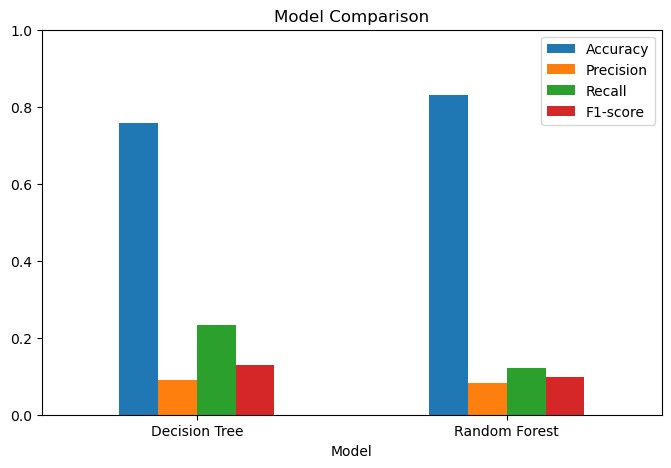

In [12]:
results = pd.DataFrame([
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Precision": precision_score(y_test, y_pred_dt),
        "Recall": recall_score(y_test, y_pred_dt),
        "F1-score": f1_score(y_test, y_pred_dt)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1-score": f1_score(y_test, y_pred_rf)
    }
])

print(results)

results.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()